# Modeling Intro: First RGB Barycentric Triangle

## Introduction

This notebook starts with code that already works and produces a meaningful result. That is often exactly what we need in science: something correct enough to explore an idea. We start with writing code in Jupyter notebooks because it is quick and easy for the programmer.

In CMSE 802, we build from that success by adding a few software engineering habits that are:

- quick to apply
- easy to understand
- high impact for readability and reuse

The goal is to build from a working concept and make code that is [***Safe, Portable, Reproducible, Robust and Literate***](https://colbrydi.github.io/Research_guidelines/Rules_for_Repos.html).

## What To Do

1. Run the code cell below to generate the triangle image.
2. Work with your team to understand what the code is doing.
3. Make one small change.
4. Re-run the code cell.
5. Observe what changed.
6. Discuss why the change helps.

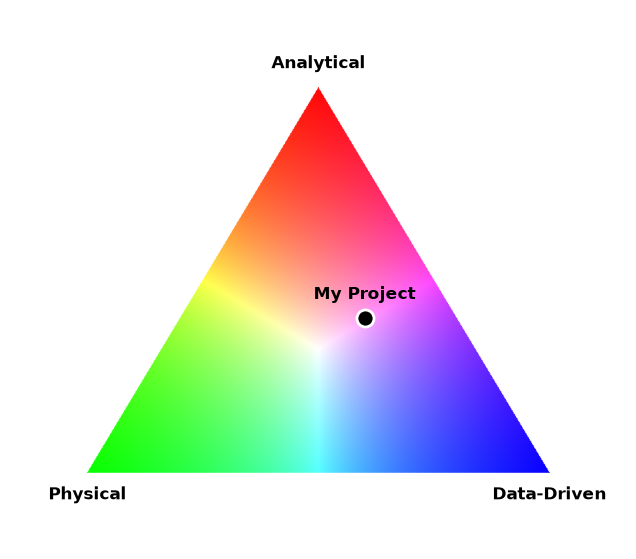

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def is_point_inside_triangle(point, vertex_a, vertex_b, vertex_c):
    """
    Determine whether a point lies inside a triangle.

    This function uses barycentric coordinates to test whether
    the point is contained within the triangle defined by three vertices.

    Parameters
    ----------
    point : numpy.ndarray
        The [x, y] coordinates of the point being tested.
    vertex_a : numpy.ndarray
        Coordinates of the first triangle vertex.
    vertex_b : numpy.ndarray
        Coordinates of the second triangle vertex.
    vertex_c : numpy.ndarray
        Coordinates of the third triangle vertex.

    Returns
    -------
    bool
        True if the point is inside the triangle, otherwise False.
    """

    vector_0 = vertex_c - vertex_a
    vector_1 = vertex_b - vertex_a
    vector_2 = point - vertex_a

    dot_00 = np.dot(vector_0, vector_0)
    dot_01 = np.dot(vector_0, vector_1)
    dot_02 = np.dot(vector_0, vector_2)
    dot_11 = np.dot(vector_1, vector_1)
    dot_12 = np.dot(vector_1, vector_2)

    denominator = dot_00 * dot_11 - dot_01 * dot_01

    barycentric_u = (
        dot_11 * dot_02 - dot_01 * dot_12
    ) / denominator

    barycentric_v = (
        dot_00 * dot_12 - dot_01 * dot_02
    ) / denominator

    return (
        barycentric_u >= 0
        and barycentric_v >= 0
        and barycentric_u + barycentric_v <= 1
    )


def generate_rgb_triangle(width=800, height=700, border=100):
    """
    Generate an RGB triangle image.

    The three vertices represent:
        Red   = Analytical
        Green = Physical
        Blue  = Data-Driven

    Parameters
    ----------
    width : int, optional
        Image width in pixels. Default is 800.
    height : int, optional
        Image height in pixels. Default is 700.
    border : int, optional
        Distance between the triangle vertices and image edges.
        Default is 100.

    Returns
    -------
    image : numpy.ndarray
        The generated RGB image.
    analytical_vertex : numpy.ndarray
        Coordinates of the red/analytical vertex.
    physical_vertex : numpy.ndarray
        Coordinates of the green/physical vertex.
    data_vertex : numpy.ndarray
        Coordinates of the blue/data-driven vertex.
    """

    # Begin with a white RGB image.
    image = np.ones((height, width, 3), dtype=float)

    # Define the three triangle vertices.
    analytical_vertex = np.array([width / 2, border])
    physical_vertex = np.array([border, height - border])
    data_vertex = np.array([width - border, height - border])

    # Use the longest triangle side as the distance scale
    # for determining color intensity.
    maximum_distance = max(
        np.linalg.norm(analytical_vertex - physical_vertex),
        np.linalg.norm(analytical_vertex - data_vertex),
        np.linalg.norm(physical_vertex - data_vertex),
    )

    # Examine every pixel in the image.
    for y_coordinate in range(height):
        for x_coordinate in range(width):

            pixel_point = np.array([x_coordinate, y_coordinate])

            # Only color pixels that are inside the triangle.
            if is_point_inside_triangle(
                pixel_point,
                analytical_vertex,
                physical_vertex,
                data_vertex,
            ):

                distance_to_analytical = np.linalg.norm(
                    pixel_point - analytical_vertex
                )

                distance_to_physical = np.linalg.norm(
                    pixel_point - physical_vertex
                )

                distance_to_data = np.linalg.norm(
                    pixel_point - data_vertex
                )

                # Convert distance from each vertex into closeness.
                red_intensity = (
                    1.0 - distance_to_analytical / maximum_distance
                )

                green_intensity = (
                    1.0 - distance_to_physical / maximum_distance
                )

                blue_intensity = (
                    1.0 - distance_to_data / maximum_distance
                )

                pixel_color = np.array(
                    [
                        red_intensity,
                        green_intensity,
                        blue_intensity,
                    ]
                )

                # Normalize so at least one RGB channel reaches
                # full intensity and the colors remain vivid.
                pixel_color /= pixel_color.max()

                image[y_coordinate, x_coordinate] = pixel_color

    return (
        image,
        analytical_vertex,
        physical_vertex,
        data_vertex,
    )


def add_project_point(
    analytical_vertex,
    physical_vertex,
    data_vertex,
    analytical_weight=1 / 3,
    physical_weight=1 / 3,
    data_weight=1 / 3,
    point_color="black",
    point_size=120,
    point_marker="o",
    project_label="My Project",
):
    """
    Plot a research project within the RGB triangle.

    The location of the project is determined by three weights:
    analytical, physical, and data-driven. These weights must be
    nonnegative and add up to 1.

    Parameters
    ----------
    analytical_vertex : numpy.ndarray
        Coordinates of the analytical vertex.
    physical_vertex : numpy.ndarray
        Coordinates of the physical vertex.
    data_vertex : numpy.ndarray
        Coordinates of the data-driven vertex.
    analytical_weight : float, optional
        Analytical contribution. Default is 1/3.
    physical_weight : float, optional
        Physical contribution. Default is 1/3.
    data_weight : float, optional
        Data-driven contribution. Default is 1/3.
    point_color : str, optional
        Color of the project marker.
    point_size : int, optional
        Size of the project marker.
    point_marker : str, optional
        Matplotlib marker style.
    project_label : str, optional
        Text displayed next to the project point.
    """

    total_weight = (
        analytical_weight
        + physical_weight
        + data_weight
    )

    # Protect against project weights that do not describe
    # a valid position inside the triangle.
    if not np.isclose(total_weight, 1.0):
        raise ValueError(
            "Analytical, physical, and data-driven weights "
            "must add up to 1."
        )

    if (
        analytical_weight < 0
        or physical_weight < 0
        or data_weight < 0
    ):
        raise ValueError(
            "Project weights cannot be negative."
        )

    # Convert the three research weights into an [x, y]
    # coordinate inside the triangle.
    project_position = (
        analytical_weight * analytical_vertex
        + physical_weight * physical_vertex
        + data_weight * data_vertex
    )

    plt.scatter(
        project_position[0],
        project_position[1],
        color=point_color,
        s=point_size,
        marker=point_marker,
        edgecolor="white",
        linewidth=2,
        zorder=5,
    )

    plt.text(
        project_position[0],
        project_position[1] - 20,
        project_label,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )


def plot_rgb_research_triangle(
    analytical_weight=0.4,
    physical_weight=0.2,
    data_weight=0.4,
    width=800,
    height=700,
    border=100,
    project_label="My Project",
    save_file=None,
):
    """
    Create, display, and optionally save an RGB research triangle.

    Parameters
    ----------
    analytical_weight : float, optional
        Analytical contribution to the project.
    physical_weight : float, optional
        Physical contribution to the project.
    data_weight : float, optional
        Data-driven contribution to the project.
    width : int, optional
        Width of the generated image.
    height : int, optional
        Height of the generated image.
    border : int, optional
        Space between the triangle and image edges.
    project_label : str, optional
        Label shown next to the project point.
    save_file : str or None, optional
        Filename for saving the figure. If None, the figure
        is displayed but not saved.
    """

    (
        image,
        analytical_vertex,
        physical_vertex,
        data_vertex,
    ) = generate_rgb_triangle(
        width=width,
        height=height,
        border=border,
    )

    plt.figure(figsize=(8, 7))
    plt.imshow(image)

    # Label each research dimension.
    plt.text(
        analytical_vertex[0],
        analytical_vertex[1] - 25,
        "Analytical",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

    plt.text(
        physical_vertex[0],
        physical_vertex[1] + 35,
        "Physical",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

    plt.text(
        data_vertex[0],
        data_vertex[1] + 35,
        "Data-Driven",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

    # Add the research project to the triangle.
    add_project_point(
        analytical_vertex,
        physical_vertex,
        data_vertex,
        analytical_weight=analytical_weight,
        physical_weight=physical_weight,
        data_weight=data_weight,
        project_label=project_label,
    )

    plt.axis("off")

    # Saving is optional.
    if save_file is not None:
        plt.savefig(
            save_file,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


# Example use:
plot_rgb_research_triangle(
    analytical_weight=0.4,
    physical_weight=0.2,
    data_weight=0.4,
    project_label="My Project",
    save_file="rgb_research_triangle.png",
)

# Improving the Triangle Generator

The code currently works and produces a useful figure.

In this section, your goal is not to change the overall behavior of the program. Instead, you will make a series of small improvements that make the code easier to understand, modify, reuse, and maintain.

As you work through these exercises, think about how your changes contribute to software that is:

- Safe
- Portable
- Reproducible
- Robust
- Literate

After each change, run the code and verify that it still produces a valid figure.

## Exercise 1: Eliminate Magic Numbers

Find the hard-coded values that define the border around the triangle.

Create a variable named:

```python
border
```

and replace the repeated raw values with the new variable.

Experiment with different values of `border` and observe how the figure changes.

### Team/Class Reflection
- What does the border represent?

The border represents the amount of empty space between the triangle's vertices and the edges of the image. For example, with `border = 100`, the lower-left vertex is 100 pixels from the left edge and 100 pixels from the bottom edge.

- Why is a named variable easier to understand than a raw number?

A raw value doesn't communicate the intent of the number, a named variable makes it clearer what the number is being used to do in the code. 

- How might this change make the code more robust?

Now only one value (`border`) needs to be changed instead of every instance of the number '100'.

- Are there any other magic numbers we should define as variables?

`width` and `height` could be.

- How could you eliminate magic numbers without a variable?

You can make values dependent on the one(s) you define. For example, `width` and `height` could easily be functions of `border` to always ensure an "optimal" figure size.

## Exercise 2: Convert the Script to a Function

The current code executes from top to bottom as a script. Now we want to make it more portable by turning it into a function:

- Refactor the code into a function using `def` that generates the triangle.
- Choose a set of inputs that would be useful to another programmer.
- Provide reasonable default values.

Test your function using several different inputs.

### Team/Class Reflection

- What did you name your function? Is the name useful?

I used `generate_rgb_triangle()` because the name immediately communicates the intent of the function.

- Which values belong as function inputs?

`width`, `height`, and `border` are all defined as function inputs, because they are the three values that the user would most reasonably want to change on a whim.

- Which values should remain internal details?

Any values that are dependent on the user-defined input variables should remain internal: details like `max_dist` don't need to be separately defined, because they already effectively are by `width`, `height`, and `border`.

- How do default arguments make software easier to use?

Defaults allow the function to work immediately without exact inputs given every time (i.e. `generate_rgb_triangle()` instead of `generate_rgb_triangle(800, 700, 100)`)

- How might this help make the code more portable?

Previously, the code was designed mainly to run once in this particular notebook. Now the triangle generator is packaged into a reusable function. Another programmer could copy or import the function and generate many different triangles without modifying its source code.

## Exercise 3: Add a Project Point

Create a new function that adds a point somewhere inside the triangle. The point should be displayed on top of the generated image. Experiment with different locations and styles.

Imagine this point represents your research project positioned within the RGB framework where RGB is:

- Red = Analytical
- Green = Physical
- Blue = Data-Driven

### Team/Class Reflection

- What did you name your new function? Is the name useful?

I named it `add_project_point()` because that is effectively the intent of the user, and intuitively what they expect to see because of the name. 

- What information should the function require?

The function reqires `red_point`, `green_point`, and `blue_point`, but those are not intuitive inputs for the user, whereas `analytical`, `physical`, and `data_driven` are what the user would prefer to define.

- What information could be optional?

The visual styling variables like `color` and `size` can have reasonable defaults for other coders.

- Would another student understand how to use your function?

Probably more easily than if the function required arbitrary pixel coordinates, because the function inputs correspond directly to the meaning of the figure.

## Exercise 4: Save the Figure

Modify the code so a user can save the generated figure to a file.

Consider whether saving should always happen, never happen, or be controlled through a function argument.

Adjust your implementation.

### Team/Class Reflection

- Why is saving generated figures useful in research?

You often need to put them somewhere, be it a research presentation, a poster, or a paper. Saving them makes them easier to export to other programs for editing and finalizing. 

- How can saved figures support reproducible workflows?

Saved figures give new users another checkpoint to make sure their workflow functioned as intended by the code creator.

- What file naming practices might help keep projects organized?

Useful naming practices for figures often communicate the contents, methodology, or the origin of the figure. For example, `rgb_triangle_CMSE802_fig2` is a lot more descriptive than `rgb_fig2` or `CMSE802_fig2` or `triangle_fig2`.

## Exercise 5: Make the Code More Literate

Imagine another student needs to use your code next semester.

Improve the code so it is easier to understand.

Possible ideas include:

- better variable names
- add comments and docstrings
- clearer function names

### Team/Class Reflection

- What change did you make?

I improved the variable names, function names, and comments throughout the program. For example, variables such as `p, d_red`, and `red_poin`t were replaced with more descriptive names such as `pixel_point`, `distance_to_analytical`, and `analytical_vertex`. I also renamed the main plotting function `plot_rgb_research_triangle()` so its purpose is slightly more obvious.

- How does it improve readability?

Descriptive names allow someone to understand what the code represents without needing to trace every variable back through the calculations. The comments explain why important sections of the code are being performed, what each function does, what inputs it accepts, and what it returns.

- How does it support literate software?

Literate software should communicate its purpose to people as well as give instructions to the computer. By using meaningful names, comments, docstrings, and clearly separated functions, the code documents the scientific idea behind the program while it performs the calculation. Another student could return to this code next semester and more easily understand both how to use it and why it works.

You are done with this notebook. Move on to the next notebook to learn how to make your code more portable using a Python library.